-> Cargando matriz simétrica desde caché...
-> Ejecutando Ripser para extraer H0...
-> Calculando intervalos de estabilidad...

======================= TOP 20 CONFIGURACIONES MÁS ESTABLES =======================
 Cantidad de H0s Persistencia (min)
      742               4.64       
      754               0.49       
      743               0.48       
      751               0.42       
      747               0.27       
      746               0.23       
      750               0.21       
      745               0.13       
      753               0.12       
      773               0.10       
      748               0.09       
      757               0.09       
      752               0.08       
      749               0.08       
      792               0.07       
      778               0.07       
      776               0.06       
      785               0.05       
      796               0.04       
      755               0.04       

-> Construyendo Dendrograma Glo

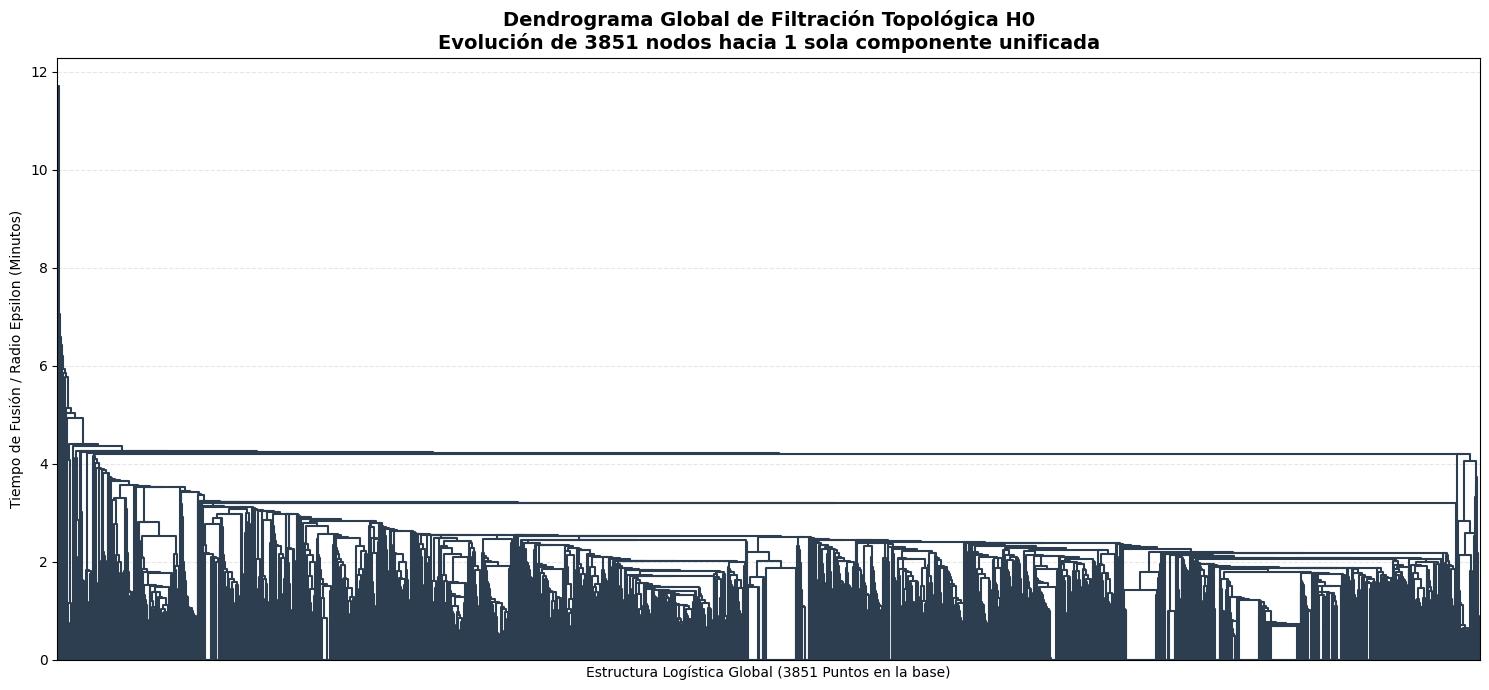

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd

# --- 1. CARGA O CÁLCULO DE LA MATRIZ SIMÉTRICA ---
archivo_crudo = Path('matriz_origen_destino.csv') 
archivo_ponderado = Path('matriz_tiempos_ponderada_simetrica.csv')

if archivo_ponderado.is_file():
    print("-> Cargando matriz simétrica desde caché...")
    df_ponderada = pd.read_csv(archivo_ponderado, index_col=0)
    df_ponderada.columns = df_ponderada.columns.astype(type(df_ponderada.index[0]))
    matrix_para_tda = df_ponderada.values
    nodos_totales = df_ponderada.index.tolist()
    n = df_ponderada.shape[0]
else:
    print("-> Procesando matriz cruda...")
    df_raw = pd.read_csv(archivo_crudo)
    df_raw['tiempo_minutos'] = df_raw['tiempo_segundos'] / 60.0
    nodos_totales = sorted(list(set(df_raw['id_origen']).union(set(df_raw['id_destino']))))
    n = len(nodos_totales)

    df_asimetrica = df_raw.pivot(index='id_origen', columns='id_destino', values='tiempo_minutos')
    df_asimetrica = df_asimetrica.reindex(index=nodos_totales, columns=nodos_totales)
    
    asym_mat = df_asimetrica.to_numpy(copy=True)
    np.fill_diagonal(asym_mat, 0)
    
    max_mat = np.maximum(asym_mat, asym_mat.T)
    min_mat = np.minimum(asym_mat, asym_mat.T)
    matrix_para_tda = (0.7 * max_mat) + (0.3 * min_mat)
    
    df_sym = pd.DataFrame(matrix_para_tda, index=nodos_totales, columns=nodos_totales)
    df_sym.to_csv(archivo_ponderado)

# --- 2. CÁLCULO DE PERSISTENCIA EXCLUSIVO PARA H0 ---
print("-> Ejecutando Ripser para extraer H0...")
dgms = ripser(matrix_para_tda, distance_matrix=True, maxdim=0)['dgms']
h0_data = dgms[0]

# --- 3. ANÁLISIS DE DURACIÓN POR CANTIDAD DE H0s ---
print("-> Calculando intervalos de estabilidad...")
# Extraemos y ordenamos de menor a mayor todos los tiempos de fusión finitos
muertes_finitas = np.sort(h0_data[np.isfinite(h0_data[:, 1]), 1])

# Creamos una línea de tiempo que arranca en 0 minutos
linea_tiempo = np.concatenate(([0.0], muertes_finitas))

registros_estabilidad = []
for i in range(len(muertes_finitas)):
    # Al inicio (i=0) hay 'n' componentes, y va bajando de 1 en 1 con cada fusión
    cantidad_h0s = n - i
    # La duración es la diferencia entre la fusión actual y la anterior
    duracion = linea_tiempo[i+1] - linea_tiempo[i]
    
    registros_cantidades = []
    registros_estabilidad.append({
        'Cantidad de H0s': cantidad_h0s,
        'Persistencia (min)': duracion
    })

# Convertir a DataFrame y ordenar por las duraciones más largas (Top 20 más estables)
df_cantidades = pd.DataFrame(registros_estabilidad)
df_top20_cantidades = df_cantidades.sort_values(by='Persistencia (min)', ascending=False).head(20).reset_index(drop=True)

# Dar formato de dos decimales a la persistencia
df_top20_cantidades['Persistencia (min)'] = df_top20_cantidades['Persistencia (min)'].map('{:,.2f}'.format)

print("\n======================= TOP 20 CONFIGURACIONES MÁS ESTABLES =======================")
print(df_top20_cantidades.to_string(index=False, justify='center'))
print("===================================================================================\n")

# --- 4. GENERACIÓN DEL DENDROGRAMA GLOBAL (De 3000+ a 1) ---
print("-> Construyendo Dendrograma Global...")
matrix_dendro = matrix_para_tda.copy()

if np.isinf(matrix_dendro).any():
    max_finito = np.max(matrix_dendro[~np.isinf(matrix_dendro)])
    matrix_dendro[np.isinf(matrix_dendro)] = max_finito * 2

np.fill_diagonal(matrix_dendro, 0)
matrix_dendro = np.maximum(matrix_dendro, matrix_dendro.T)

distancias_condensadas = ssd.squareform(matrix_dendro)
Z = sch.linkage(distancias_condensadas, method='single')

plt.figure(figsize=(15, 7))
plt.title(f"Dendrograma Global de Filtración Topológica H0\nEvolución de {n} nodos hacia 1 sola componente unificada", fontsize=14, fontweight='bold')
plt.xlabel(f"Estructura Logística Global ({n} Puntos en la base)")
plt.ylabel("Tiempo de Fusión / Radio Epsilon (Minutos)")

sch.dendrogram(
    Z, 
    no_labels=True,           
    above_threshold_color='#2c3e50', 
    color_threshold=0         
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# --- 3. ANÁLISIS DE DURACIÓN POR CANTIDAD DE H0s (CORREGIDO) ---
print("-> Calculando intervalos de estabilidad en la red activa...")
# Extraemos y ordenamos de menor a mayor solo los tiempos de fusión reales (finitos)
muertes_finitas = np.sort(h0_data[np.isfinite(h0_data[:, 1]), 1])

# Creamos una línea de tiempo que arranca en 0 minutos
linea_tiempo = np.concatenate(([0.0], muertes_finitas))

registros_estabilidad = []
# El tamaño de la red conectada real es el número de fusiones finitas + 1
n_activos = len(muertes_finitas) + 1

for i in range(len(muertes_finitas)):
    # El conteo ahora bajará correctamente hasta llegar a 2 en la última fusión
    cantidad_h0s = n_activos - i
    # La duración es la diferencia entre la fusión actual y la anterior
    duracion = linea_tiempo[i+1] - linea_tiempo[i]
    
    registros_estabilidad.append({
        'Cantidad de H0s': cantidad_h0s,
        'Persistencia (min)': duracion
    })

# Convertir a DataFrame y ordenar por las duraciones más largas
df_cantidades = pd.DataFrame(registros_estabilidad)
df_top20_cantidades = df_cantidades.sort_values(by='Persistencia (min)', ascending=False).head(20).reset_index(drop=True)

# Dar formato de dos decimales a la persistencia
df_top20_cantidades['Persistencia (min)'] = df_top20_cantidades['Persistencia (min)'].map('{:,.2f}'.format)

print("\n======================= TOP 20 CONFIGURACIONES MÁS ESTABLES =======================")
print(df_top20_cantidades.to_string(index=False, justify='center'))
print("===================================================================================\n")

-> Calculando intervalos de estabilidad en la red activa...

======================= TOP 20 CONFIGURACIONES MÁS ESTABLES =======================
 Cantidad de H0s Persistencia (min)
        2               4.64       
       14               0.49       
        3               0.48       
       11               0.42       
        7               0.27       
        6               0.23       
       10               0.21       
        5               0.13       
       13               0.12       
       33               0.10       
        8               0.09       
       17               0.09       
       12               0.08       
        9               0.08       
       52               0.07       
       38               0.07       
       36               0.06       
       45               0.05       
       56               0.04       
       15               0.04       



-> Cargando matriz simétrica desde caché...
-> Calculando estructura jerárquica H0...
Generando animación de clusters...
¡Listo! Animación de clusters guardada como filtracion_clusters_h0_cdmx.gif

-> Generando mapa estático de la fase de Máxima Estabilidad (H0 = 2)...


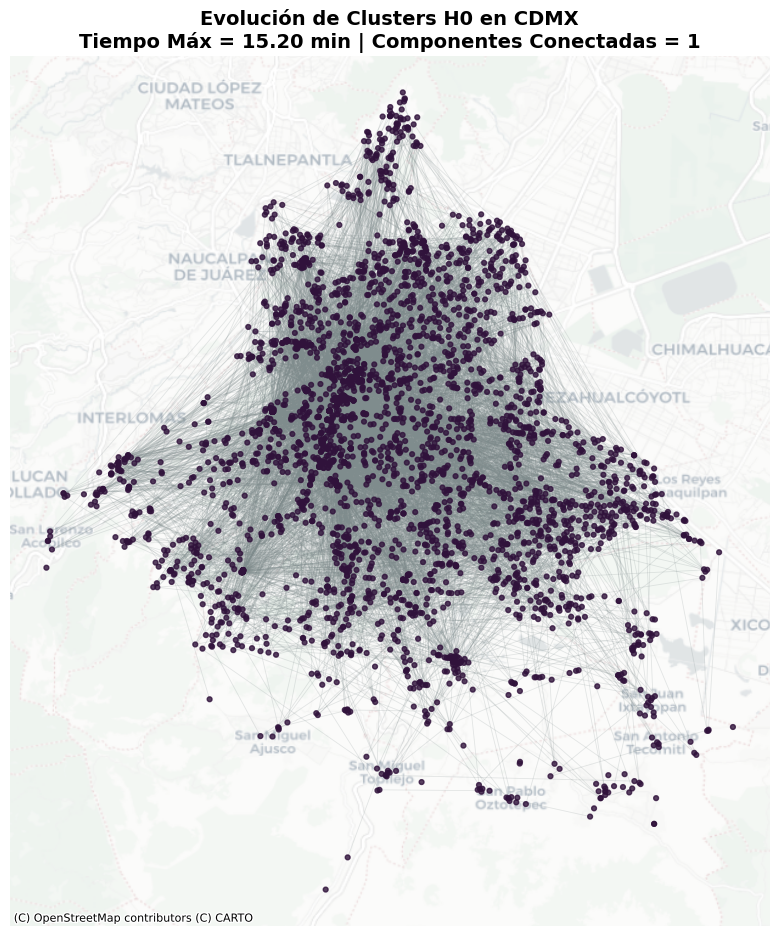

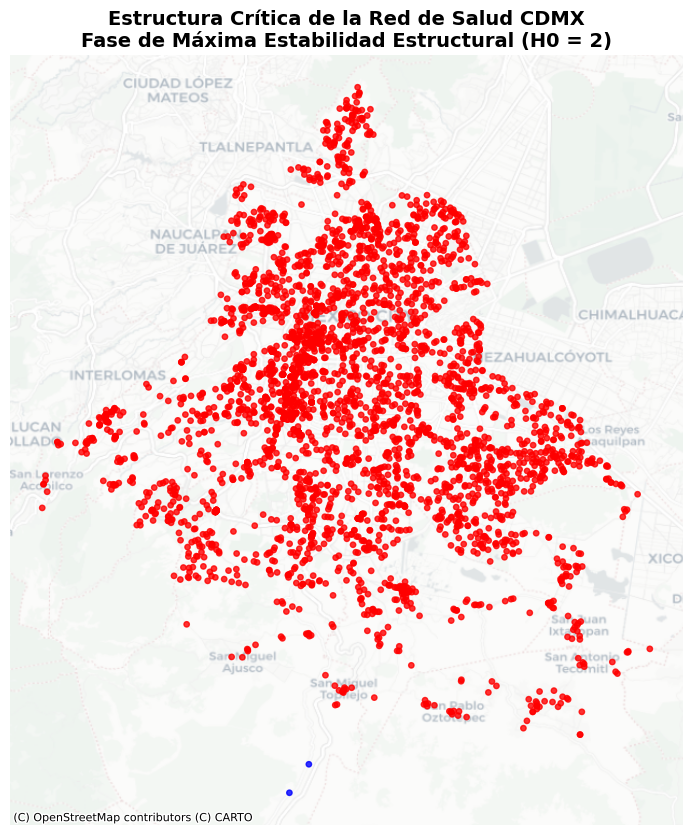

¡Mapa guardado con éxito! Revisa el archivo: mapa_macro_clusters_h0_2.png


In [8]:
from pathlib import Path
import contextily as ctx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
from ripser import ripser
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd

# --- 1. CARGA O CÁLCULO DE LA MATRIZ SIMÉTRICA ---
archivo_crudo = Path('matriz_origen_destino.csv') 
archivo_ponderado = Path('matriz_tiempos_ponderada_simetrica.csv')

if archivo_ponderado.is_file():
    print("-> Cargando matriz simétrica desde caché...")
    df_ponderada = pd.read_csv(archivo_ponderado, index_col=0)
    df_ponderada.columns = df_ponderada.columns.astype(type(df_ponderada.index[0]))
    matrix_para_tda = df_ponderada.values
    n = df_ponderada.shape[0]
    nodos_totales = df_ponderada.index.tolist()
else:
    print("-> Procesando matriz cruda...")
    df_raw = pd.read_csv(archivo_crudo)
    df_raw['tiempo_minutos'] = df_raw['tiempo_segundos'] / 60.0
    nodos_totales = sorted(list(set(df_raw['id_origen']).union(set(df_raw['id_destino']))))
    n = len(nodos_totales)

    df_asimetrica = df_raw.pivot(index='id_origen', columns='id_destino', values='tiempo_minutos')
    df_asimetrica = df_asimetrica.reindex(index=nodos_totales, columns=nodos_totales)
    
    asym_mat = df_asimetrica.to_numpy(copy=True)
    np.fill_diagonal(asym_mat, 0)
    
    max_mat = np.maximum(asym_mat, asym_mat.T)
    min_mat = np.minimum(asym_mat, asym_mat.T)
    matrix_para_tda = (0.7 * max_mat) + (0.3 * min_mat)
    
    df_sym = pd.DataFrame(matrix_para_tda, index=nodos_totales, columns=nodos_totales)
    df_sym.to_csv(archivo_ponderado)

# --- 2. CÁLCULO H0 COMPLETO (LINKAGE) PARA CLUSTERING ---
print("-> Calculando estructura jerárquica H0...")
matrix_dendro = matrix_para_tda.copy()
if np.isinf(matrix_dendro).any():
    max_finito = np.max(matrix_dendro[~np.isinf(matrix_dendro)])
    matrix_dendro[np.isinf(matrix_dendro)] = max_finito * 2
np.fill_diagonal(matrix_dendro, 0)
matrix_dendro = np.maximum(matrix_dendro, matrix_dendro.T)

distancias_condensadas = ssd.squareform(matrix_dendro)
Z = sch.linkage(distancias_condensadas, method='single')

# --- 3. PROCESAMIENTO GEOMÉTRICO Y COORDENADAS REALES ---
df = pd.read_csv('denue_inegi_62_.csv', encoding="latin-1")
filter_data = df[df["cve_ent"].isin([9])]
codigos = [621111, 621112, 621115, 621116, 621491, 621492, 622111, 622112]
df_coords = filter_data[filter_data['codigo_act'].isin(codigos)].set_index('id')
df_coords = df_coords.reindex(nodos_totales)

lats = df_coords['latitud'].values
lons = df_coords['longitud'].values
points_geo = np.column_stack((lons, lats)) # Mantiene forma (n, 2) intacta evitando errores de índice

# --- 4. TDA AVANZADO (FILTRACIÓN DE H1) ---
resultado_ripser = ripser(matrix_para_tda, distance_matrix=True, maxdim=1, do_cocycles=True)
dgms = resultado_ripser['dgms']
cocycles_h1_totales = resultado_ripser['cocycles'][1] if len(resultado_ripser['cocycles']) > 1 else []
h1_data = dgms[1] if len(dgms) > 1 else np.empty((0, 2))

# Límites de vista de tiempo
if len(h1_data) > 0:
    tiempos_muerte_h1 = h1_data[np.isfinite(h1_data[:, 1]), 1]
    max_muerte_h1 = np.max(tiempos_muerte_h1) if len(tiempos_muerte_h1) > 0 else np.max(matrix_para_mds)
else:
    max_muerte_h1 = np.max(matrix_para_tda[~np.isinf(matrix_para_tda)])

limite_vista = max_muerte_h1 * 1.05

# --- 5. CONFIGURACIÓN DE LA ANIMACIÓN CON CLUSTERS DINÁMICOS ---
fig, ax_geo = plt.subplots(figsize=(10, 10))
plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

# Inicializamos los nodos con un color base. Usamos el mapa de color 'turbo' o 'tab20' para distinguir clusters
labels_iniciales = np.arange(n)
scatter_nodes = ax_geo.scatter(points_geo[:, 0], points_geo[:, 1], c=labels_iniciales, 
                               cmap='turbo', s=12, zorder=4, alpha=0.8)

# Ajuste de límites geográficos ignorando los NaNs de la periferia sin datos
valid_lons = points_geo[np.isfinite(points_geo[:, 0]), 0]
valid_lats = points_geo[np.isfinite(points_geo[:, 1]), 1]
margen = 0.02 
ax_geo.set_xlim(np.min(valid_lons) - margen, np.max(valid_lons) + margen)
ax_geo.set_ylim(np.min(valid_lats) - margen, np.max(valid_lats) + margen)

ax_geo.set_aspect('equal')
ax_geo.set_axis_off()
ctx.add_basemap(ax_geo, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, alpha=0.7)

edge_collection_base = LineCollection([], colors='#7f8c8d', linewidths=0.6, alpha=0.2, zorder=1)
ax_geo.add_collection(edge_collection_base)

num_frames = 80
valores_epsilon = np.linspace(0.0, limite_vista, num_frames)

def animate(frame):
    epsilon = valores_epsilon[frame]
    
    # A) CALCULO DE CLUSTERS EN ESTE EPSILON (Umbral de distancia = 2 * epsilon)
    # Fcluster agrupa automáticamente los elementos según la distancia actual del grafo
    labels = sch.fcluster(Z, t=2 * epsilon, criterion='distance')
    
    # Contar cuántos componentes activos reales (excluyendo islas aisladas si deseas)
    n_clusters_actuales = len(np.unique(labels))
    
    # B) Actualizar títulos y colores de los nodos
    ax_geo.set_title(f"Evolución de Clusters H0 en CDMX\nTiempo Máx = {epsilon:.2f} min | Componentes Conectadas = {n_clusters_actuales}", 
                     fontsize=14, fontweight='bold')
    
    scatter_nodes.set_array(labels)
    # Forzar al mapa de color a reajustarse para aprovechar todo el espectro dinámico
    scatter_nodes.set_clim(vmin=labels.min(), vmax=labels.max())
    
    # C) Dibujar conexiones físicas (Andamiaje)
    ij_conexiones = np.argwhere((matrix_para_tda <= 2 * epsilon) & (matrix_para_tda > 0))
    if len(ij_conexiones) > 0:
        ij_conexiones = ij_conexiones[ij_conexiones[:, 0] < ij_conexiones[:, 1]]
        p_start = points_geo[ij_conexiones[:, 0]]
        p_end = points_geo[ij_conexiones[:, 1]]
        
        if len(p_start) > 8000:
            indices_muestra = np.random.choice(len(p_start), 8000, replace=False)
            p_start = p_start[indices_muestra]
            p_end = p_end[indices_muestra]

        segments_base = np.stack((p_start, p_end), axis=1)
        edge_collection_base.set_segments(segments_base)
    else:
        edge_collection_base.set_segments([])
        
    return scatter_nodes, edge_collection_base

print("Generando animación de clusters...")
ani = animation.FuncAnimation(fig, animate, frames=num_frames, interval=250, blit=False)
nombre_gif = 'filtracion_clusters_h0_cdmx.gif'
ani.save(nombre_gif, writer='pillow', fps=5)
print(f"¡Listo! Animación de clusters guardada como {nombre_gif}")

# ==============================================================================
# 6. EXTRACCIÓN ESTÁTICA DE LA CONFIGURACIÓN ULTRA-ESTABLE (H0 = 2)
# ==============================================================================
print("\n-> Generando mapa estático de la fase de Máxima Estabilidad (H0 = 2)...")
fig_2c, ax_2c = plt.subplots(figsize=(10, 10))

# Extraemos exactamente los 2 macro-clusters de la ciudad
labels_2 = sch.fcluster(Z, t=2, criterion='maxclust')

# Graficamos usando un mapa bicromático (ej. Red y Blue) para ver la división clara
sc_2c = ax_2c.scatter(points_geo[:, 0], points_geo[:, 1], c=labels_2, 
                      cmap='bwr', s=15, zorder=4, alpha=0.8)

ax_2c.set_xlim(np.min(valid_lons) - margen, np.max(valid_lons) + margen)
ax_2c.set_ylim(np.min(valid_lats) - margen, np.max(valid_lats) + margen)
ax_2c.set_aspect('equal')
ax_2c.set_axis_off()
ctx.add_basemap(ax_2c, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, alpha=0.7)

ax_2c.set_title("Estructura Crítica de la Red de Salud CDMX\nFase de Máxima Estabilidad Estructural (H0 = 2)", 
                fontsize=14, fontweight='bold')

foto_estatica = 'mapa_macro_clusters_h0_2.png'
plt.savefig(foto_estatica, dpi=300, bbox_inches='tight')
plt.show()
print(f"¡Mapa guardado con éxito! Revisa el archivo: {foto_estatica}")

In [ ]:
from matplotlib.widgets import Slider

# --- 5. CÁLCULO DEL TIEMPO LÍMITE (H0 = 1 + 20 SEGUNDOS) ---
# El último elemento de muertes_finitas es el minuto exacto donde la red activa se vuelve 1 sola componente
tiempo_h0_1 = muertes_finitas[-1]
# Sumamos 20 segundos expresados en minutos
limite_slider = tiempo_h0_1 + (20.0 / 60.0)

print(f"-> Red unificada (H0=1) en: {tiempo_h0_1:.2f} min.")
print(f"-> El Slider se extenderá hasta: {limite_slider:.2f} min (+20 segundos).")

# --- 6. CONFIGURACIÓN DE LA INTERFAZ GRÁFICA CON SLIDER ---
# Dejamos espacio abajo para colocar el control deslizante
fig, ax_geo = plt.subplots(figsize=(10, 11))
plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.15)

# Inicializamos los nodos en t=0 (cada uno es su propio cluster, usamos 'turbo' para variedad de color)
labels_iniciales = np.arange(n)
scatter_nodes = ax_geo.scatter(points_geo[:, 0], points_geo[:, 1], c=labels_iniciales, 
                               cmap='turbo', s=12, zorder=4, alpha=0.8)

# Ajuste de límites geográficos del mapa CDMX
valid_lons = points_geo[np.isfinite(points_geo[:, 0]), 0]
valid_lats = points_geo[np.isfinite(points_geo[:, 1]), 1]
margen = 0.02 
ax_geo.set_xlim(np.min(valid_lons) - margen, np.max(valid_lons) + margen)
ax_geo.set_ylim(np.min(valid_lats) - margen, np.max(valid_lats) + margen)

ax_geo.set_aspect('equal')
ax_geo.set_axis_off()
ctx.add_basemap(ax_geo, crs="EPSG:4326", source=ctx.providers.CartoDB.Positron, alpha=0.7)

# Colección de líneas para las conexiones de los caminos (andamiaje)
edge_collection_base = LineCollection([], colors='#7f8c8d', linewidths=0.6, alpha=0.2, zorder=1)
ax_geo.add_collection(edge_collection_base)

# --- CREACIÓN DEL COMPONENTE SLIDER ---
# Posición en la pantalla: [izquierda, abajo, ancho, alto]
ax_slider = plt.axes([0.15, 0.06, 0.70, 0.03], facecolor='#ecf0f1')
slider_tiempo = Slider(
    ax=ax_slider,
    label='Tiempo Traslado (min) ',
    valmin=0.0,
    valmax=limite_slider,
    valinit=0.0,
    valfmt='%1.2f min',
    color='#2980b9'
)

# --- FUNCIÓN DE ACTUALIZACIÓN DINÁMICA ---
def update(val):
    epsilon = slider_tiempo.val
    
    # 1. Calcular clusters según la posición actual del Slider (Distancia = 2 * epsilon)
    labels = sch.fcluster(Z, t=2 * epsilon, criterion='distance')
    
    # Contar cuántas componentes quedan vivas en este minuto exacto
    # Restamos las islas infinitas que no pertenecen a la red conectada real
    n_islas_inf = np.sum(~np.isfinite(h0_data[:, 1]))
    n_clusters_actuales = max(1, len(np.unique(labels)) - n_islas_inf + 1)
    
    if epsilon >= tiempo_h0_1:
        n_clusters_actuales = 1 # Forzar visualmente el 1 si ya pasamos el tiempo límite activo
    
    # 2. Actualizar título y colores de los nodos
    ax_geo.set_title(f"Explorador de Clusters H0 en CDMX\nTiempo Seleccionado = {epsilon:.2f} min | Componentes Activas = {n_clusters_actuales}", 
                     fontsize=13, fontweight='bold')
    
    scatter_nodes.set_array(labels)
    scatter_nodes.set_clim(vmin=labels.min(), vmax=labels.max())
    
    # 3. Actualizar líneas de conexión del Grafo
    ij_conexiones = np.argwhere((matrix_para_tda <= 2 * epsilon) & (matrix_para_tda > 0))
    if len(ij_conexiones) > 0:
        ij_conexiones = ij_conexiones[ij_conexiones[:, 0] < ij_conexiones[:, 1]]
        p_start = points_geo[ij_conexiones[:, 0]]
        p_end = points_geo[ij_conexiones[:, 1]]
        
        # Muestreo adaptativo para evitar saturación de memoria en renderizado interactivo
        if len(p_start) > 8000:
            indices_muestra = np.random.choice(len(p_start), 8000, replace=False)
            p_start = p_start[indices_muestra]
            p_end = p_end[indices_muestra]

        segments_base = np.stack((p_start, p_end), axis=1)
        edge_collection_base.set_segments(segments_base)
    else:
        edge_collection_base.set_segments([])
    
    # Redibujar la figura de forma eficiente
    fig.canvas.draw_idle()

# Vinculamos el movimiento del slider con nuestra función
slider_tiempo.on_changed(update)

# Inicializamos la vista llamando a la función una vez
update(0.0)

print("-> Abriendo mapa interactivo. Mueve el Slider inferior para explorar...")
plt.show()